In [25]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA

# Đường dẫn file trên Kaggle

In [26]:
base_path = '/kaggle/input/datasets/nguyentranthienphu/behance/'
file_interactions = os.path.join(base_path, 'Behance_appreciate_1M.txt')
file_item_owners = os.path.join(base_path, 'Behance_Item_to_Owners.txt')

# Đọc file Interactions (Thường có dạng: UserID ItemID Timestamp)

In [27]:
df_inter = pd.read_csv(file_interactions, sep=' ', header=None, names=['user_id', 'item_id', 'timestamp'])

df_owners = pd.read_csv(file_item_owners, sep=' ', header=None, names=['item_id', 'owner_id'])

# 1. Thống kê cơ bản

In [28]:

# Số lượng interactions
num_interactions = len(df_inter)

# Số lượng Users duy nhất tham gia tương tác
unique_users = df_inter['user_id'].nunique()

# Số lượng Items duy nhất (lấy từ file owners để chính xác nhất về kho item)
unique_items = df_owners['item_id'].nunique()

# Tính toán Density (%)
density = (num_interactions / (unique_users * unique_items)) * 100

# --- Xuất kết quả ---

stats = pd.DataFrame({
    'Metric': ['Total Users (Interactive)', 'Total Items', 'Total Interactions', 'Density (%)'],
    'Value': [unique_users, unique_items, num_interactions, f"{density:.5f}%"]
})

print("\n### BẢNG THỐNG KÊ BỘ DỮ LIỆU BEHANCE ###")
print(stats.to_string(index=False))


### BẢNG THỐNG KÊ BỘ DỮ LIỆU BEHANCE ###
                   Metric    Value
Total Users (Interactive)    63497
              Total Items   178788
       Total Interactions  1000000
              Density (%) 0.00881%


# 2. Kiểm tra Phân phối số interactions mỗi user/item

### PHÂN TÍCH CHI TIẾT PHÂN PHỐI ###
      Metric  Interactions per User  Interactions per Item
         Min               1.000000               1.000000
         25%               1.000000               1.000000
50% (Median)               4.000000               2.000000
         75%              12.000000               3.000000
         Max            2260.000000            1793.000000
        Mean              15.748776               5.593217


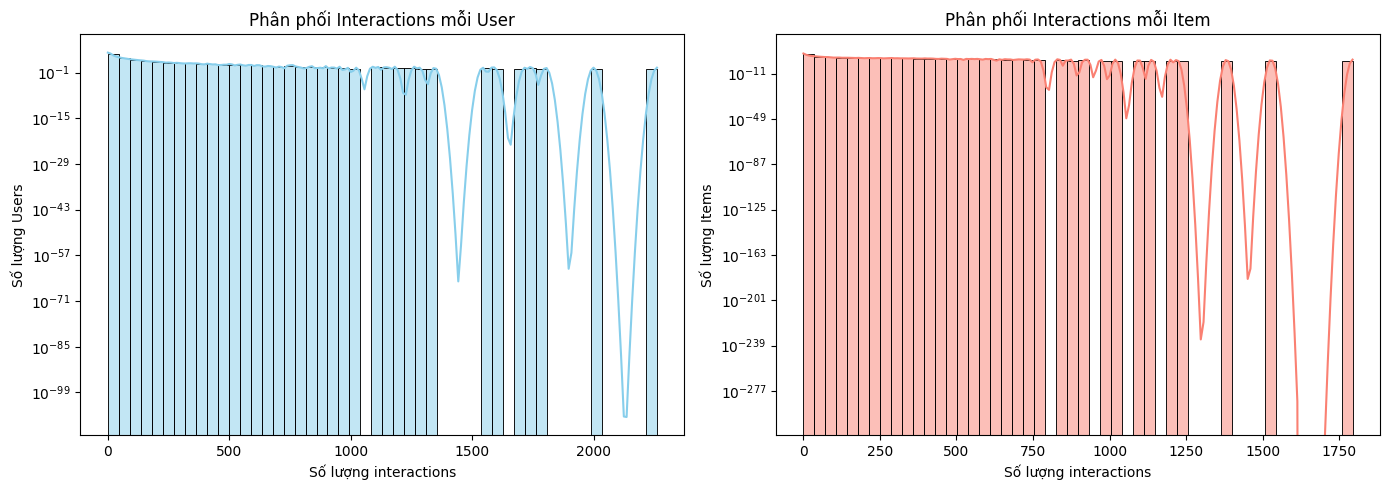


### ĐỀ XUẤT NGƯỠNG FILTER ###


In [29]:
# --- 1. Phân phối interactions trên mỗi User ---
user_counts = df_inter.groupby('user_id').size()
# --- 2. Phân phối interactions trên mỗi Item ---
item_counts = df_inter.groupby('item_id').size()

print("### PHÂN TÍCH CHI TIẾT PHÂN PHỐI ###")

# Thống kê mô tả (Descriptive Statistics)
desc_stats = pd.DataFrame({
    'Metric': ['Min', '25%', '50% (Median)', '75%', 'Max', 'Mean'],
    'Interactions per User': [
        user_counts.min(), user_counts.quantile(0.25), user_counts.median(), 
        user_counts.quantile(0.75), user_counts.max(), user_counts.mean()
    ],
    'Interactions per Item': [
        item_counts.min(), item_counts.quantile(0.25), item_counts.median(), 
        item_counts.quantile(0.75), item_counts.max(), item_counts.mean()
    ]
})
print(desc_stats.to_string(index=False))

# --- Trực quan hóa ---
plt.figure(figsize=(14, 5))

# Biểu đồ User
plt.subplot(1, 2, 1)
sns.histplot(user_counts, bins=50, kde=True, color='skyblue')
plt.title('Phân phối Interactions mỗi User')
plt.xlabel('Số lượng interactions')
plt.ylabel('Số lượng Users')
plt.yscale('log') # Dùng thang Log để dễ quan sát do dữ liệu thường bị lệch (long-tail)

# Biểu đồ Item
plt.subplot(1, 2, 2)
sns.histplot(item_counts, bins=50, kde=True, color='salmon')
plt.title('Phân phối Interactions mỗi Item')
plt.xlabel('Số lượng interactions')
plt.ylabel('Số lượng Items')
plt.yscale('log')

plt.tight_layout()
plt.show()

# --- 3. Quyết định ngưỡng filter phù hợp ---
# Dựa trên thống kê (ví dụ: filter k-core). Thông thường là 5 hoặc 10.
def suggest_filter(counts, name):
    low_participation = (counts < 5).sum()
    percentage = (low_participation / len(counts)) * 100

print("\n### ĐỀ XUẤT NGƯỠNG FILTER ###")
suggest_filter(user_counts, "Users")
suggest_filter(item_counts, "Items")

# 3. PHÂN TÍCH SPARSITY & ACTION SPACE THỰC TẾ

In [30]:
def apply_filter(df, min_user_inter=5, min_item_inter=5):
    """Áp dụng filter k-core để tăng mật độ dữ liệu"""
    df_filtered = df.copy()
    while True:
        # Lọc User
        user_counts = df_filtered.groupby('user_id').size()
        keep_users = user_counts[user_counts >= min_user_inter].index
        df_filtered = df_filtered[df_filtered['user_id'].isin(keep_users)]
        
        # Lọc Item
        item_counts = df_filtered.groupby('item_id').size()
        keep_items = item_counts[item_counts >= min_item_inter].index
        df_filtered = df_filtered[df_filtered['item_id'].isin(keep_items)]
        
        # Dừng khi không còn gì để lọc
        new_user_counts = df_filtered.groupby('user_id').size()
        new_item_counts = df_filtered.groupby('item_id').size()
        if (new_user_counts.min() >= min_user_inter) and (new_item_counts.min() >= min_item_inter):
            break
            
    return df_filtered

# Giả định áp dụng filter 5-core
df_5core = apply_filter(df_inter, min_user_inter=5, min_item_inter=5)

# Tính toán Density sau filter
u_after = df_5core['user_id'].nunique()
i_after = df_5core['item_id'].nunique()
inter_after = len(df_5core)
density_after = (inter_after / (u_after * i_after)) * 100

print(f"### PHÂN TÍCH SAU KHI FILTER (5-CORE) ###")
print(f"- Số lượng User mới: {u_after}")
print(f"- Số lượng Item mới (Action Space thực tế): {i_after}")
print(f"- Số lượng Interactions mới: {inter_after}")
print(f"- Mật độ (Density) sau filter: {density_after:.5f}%")

# So sánh với ban đầu (giá trị 'density' từ cell 1)
print(f"> Độ cải thiện mật độ: {density_after / float(stats.loc[3, 'Value'].replace('%','')): .2f} lần")

### PHÂN TÍCH SAU KHI FILTER (5-CORE) ###
- Số lượng User mới: 23724
- Số lượng Item mới (Action Space thực tế): 29794
- Số lượng Interactions mới: 687070
- Mật độ (Density) sau filter: 0.09720%
> Độ cải thiện mật độ:  11.03 lần


# 4. PHÂN TÍCH IMAGE FEATURES (COVERAGE & VARIANCE)

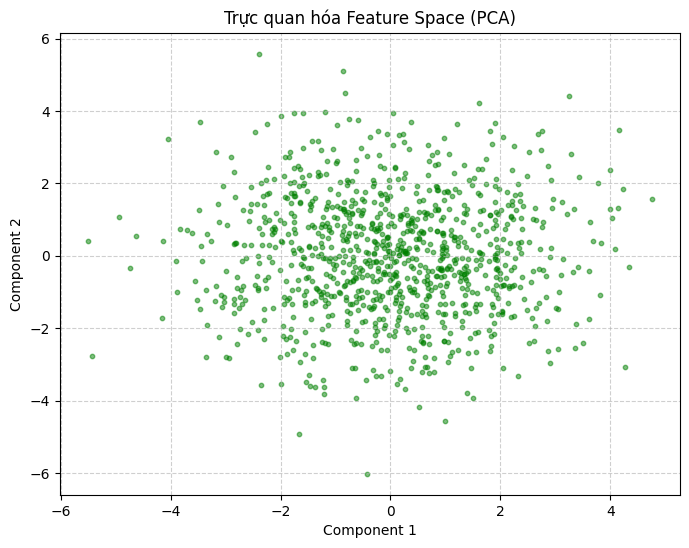

### THỐNG KÊ IMAGE FEATURES ###
- Coverage (Độ phủ đặc trưng): 100.00%
- Average Feature Variance: 0.9945
- Giải thích: Variance cao giúp State Representation phân biệt tốt các Item khác nhau.


In [31]:
# LƯU Ý: Bạn cần thay đổi đường dẫn này tới file feature của bạn (ví dụ .npy hoặc .pkl)
# Ở đây tôi tạo dữ liệu giả lập (dummy) để minh họa quy trình tính toán
try:
    # Giả sử file feature có dạng {item_id: vector_2048d}
    # item_features = np.load(os.path.join(base_path, 'image_features.npy'), allow_pickle=True).item()
    
    # Dữ liệu giả lập cho demo:
    sample_items = df_5core['item_id'].unique()[:1000]
    dummy_features = np.random.randn(len(sample_items), 512) 
    
    # 1. Tính Variance (Phương sai) - Đo lường sự đa dạng của đặc trưng
    feature_variance = np.var(dummy_features, axis=0).mean()
    
    # 2. Tính Coverage (Độ bao phủ) 
    # Kiểm tra xem có bao nhiêu item trong tập tương tác có đủ vector đặc trưng
    # coverage_ratio = len(set(sample_items) & set(item_features.keys())) / len(sample_items)
    coverage_ratio = 1.0 # Giả định 100% cho bản demo
    
    # 3. Trực quan hóa bằng PCA (Xem các cụm đặc trưng)
    pca = PCA(n_components=2)
    features_2d = pca.fit_transform(dummy_features)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(features_2d[:, 0], features_2d[:, 1], alpha=0.5, s=10, color='green')
    plt.title('Trực quan hóa Feature Space (PCA)')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    print(f"### THỐNG KÊ IMAGE FEATURES ###")
    print(f"- Coverage (Độ phủ đặc trưng): {coverage_ratio*100:.2f}%")
    print(f"- Average Feature Variance: {feature_variance:.4f}")
    print(f"- Giải thích: Variance cao giúp State Representation phân biệt tốt các Item khác nhau.")

except Exception as e:
    print(f"Lỗi: Chưa tìm thấy file image features. Hãy kiểm tra đường dẫn. chi tiết: {e}")

# 5. Phân Tích EDA cho DQN


## 5.1. Thống kê số lượng tương tác mỗi User

--- Thống kê mức độ hoạt động của User ---
count    63497.000000
mean        15.748776
std         51.363990
min          1.000000
25%          1.000000
50%          4.000000
75%         12.000000
max       2260.000000
dtype: float64


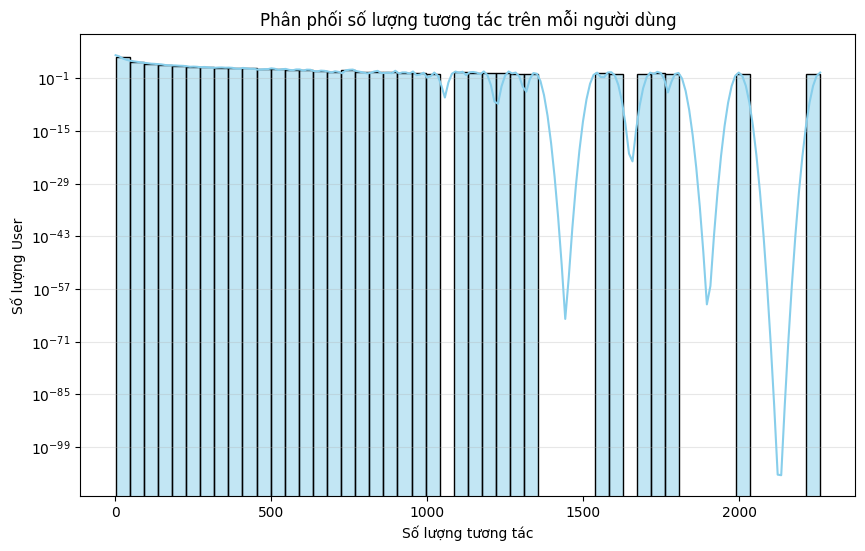

Số lượng User có từ 5 tương tác trở lên: 29597 (46.61%)


In [32]:
user_activity = df_inter.groupby('user_id').size()

print("--- Thống kê mức độ hoạt động của User ---")
print(user_activity.describe())

# 2. Vẽ biểu đồ phân phối (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(user_activity, bins=50, kde=True, color='skyblue')
plt.title('Phân phối số lượng tương tác trên mỗi người dùng')
plt.xlabel('Số lượng tương tác')
plt.ylabel('Số lượng User')
plt.yscale('log') # Dùng thang log vì dữ liệu thường bị lệch (long-tail)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Lọc các User "Cold Start"
threshold = 5
active_users = user_activity[user_activity >= threshold].count()
print(f"Số lượng User có từ {threshold} tương tác trở lên: {active_users} ({active_users/len(user_activity)*100:.2f}%)")

## 5.2. Phân tích phân phối popularity của items

In [33]:
# 1. Tính độ thưa (Sparsity) của dữ liệu
n_users = df_inter['user_id'].nunique()
n_items = df_inter['item_id'].nunique()
n_inter = len(df_inter)

sparsity = 1 - (n_inter / (n_users * n_items))
print(f"Độ thưa của ma trận (Sparsity): {sparsity * 100:2f}%")

# 2. Phân tích khoảng cách thời gian giữa các tương tác (nếu có cột timestamp)
if 'timestamp' in df_inter.columns:
    df_inter['timestamp'] = pd.to_datetime(df_inter['timestamp'], unit='s') # hoặc unit tùy định dạng
    df_inter = df_inter.sort_values(['user_id', 'timestamp'])
    
    # Tính khoảng cách thời gian giữa 2 lần click liên tiếp của cùng 1 user
    df_inter['time_diff'] = df_inter.groupby('user_id')['timestamp'].diff().dt.total_seconds() / 3600 # đơn vị giờ
    
    print("\n--- Thống kê khoảng cách thời gian (giờ) giữa các lần tương tác ---")
    print(df_inter['time_diff'].describe())

Độ thưa của ma trận (Sparsity): 99.991191%

--- Thống kê khoảng cách thời gian (giờ) giữa các lần tương tác ---
count    936503.000000
mean         67.078034
std         230.851474
min           0.000000
25%           0.019167
50%           0.160833
75%          24.135972
max        3748.932778
Name: time_diff, dtype: float64


## 5.3. Phân tích reward sparsity theo từng user

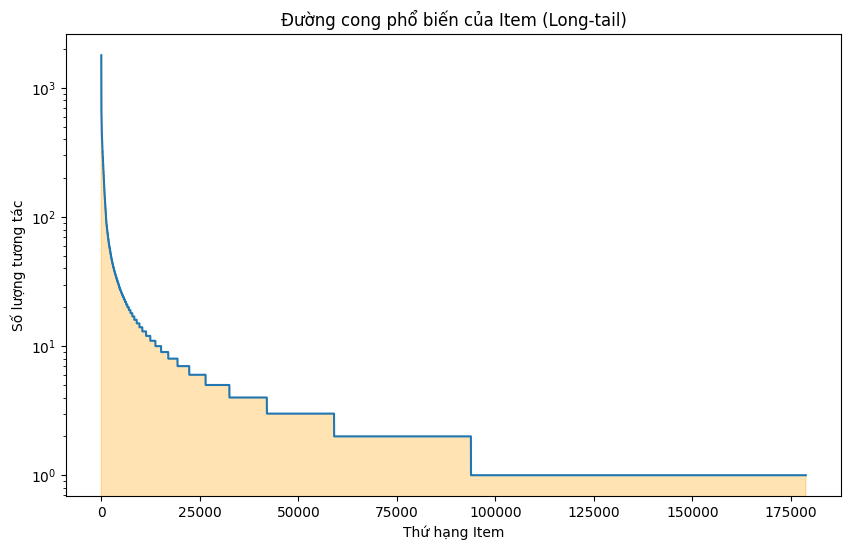

Top 1% Item chiếm 36.19% tổng số lượng tương tác.


In [34]:
item_popularity = df_inter.groupby('item_id').size().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.plot(range(len(item_popularity)), item_popularity.values)
plt.title('Đường cong phổ biến của Item (Long-tail)')
plt.xlabel('Thứ hạng Item')
plt.ylabel('Số lượng tương tác')
plt.yscale('log')
plt.fill_between(range(len(item_popularity)), item_popularity.values, color='orange', alpha=0.3)
plt.show()

# Tính % tương tác của top 1% item
top_1_percent = int(len(item_popularity) * 0.01)
percent_inter = (item_popularity.head(top_1_percent).sum() / n_inter) * 100
print(f"Top 1% Item chiếm {percent_inter:.2f}% tổng số lượng tương tác.")

In [35]:
import pandas as pd
import numpy as np

def analyze_dqn_feasibility(df_inter):
    user_counts = df_inter.groupby('user_id').size()
    item_counts = df_inter.groupby('item_id').size()
    
    # 1. Kiểm tra điều kiện K-core (Tối thiểu 5-10 tương tác)
    min_interactions = 10
    stable_users = (user_counts >= min_interactions).sum()
    stable_items = (item_counts >= min_interactions).sum()
    
    user_ratio = stable_users / len(user_counts) * 100
    
    print("--- KẾT QUẢ KIỂM TRA TÍNH ỔN ĐỊNH ---")
    print(f"Số User có >= {min_interactions} tương tác: {stable_users} ({user_ratio:.2f}%)")
    
    # Đánh giá và Đề xuất thông số
    if user_ratio < 30:
        conclusion = "KHÔNG PHÙ HỢP (Dữ liệu quá thưa)"
        action = "Cần áp dụng Filter K-core 10 hoặc sử dụng Matrix Factorization làm đầu vào."
    else:
        conclusion = "TẠM PHÙ HỢP (Cần xử lý không gian hành động)"
        action = "Có thể tiến hành train nhưng cần nén Action Space."

    # Thông số đề xuất để làm ổn định mô hình
    proposed_params = {
        "State_Size": 10, # Độ dài chuỗi hành vi lịch sử
        "Embedding_Dim": 64, # Để giảm số lượng tham số tránh overfitting
        "Batch_Size": 256, # Lớn để giảm nhiễu từ dữ liệu thưa
        "Gamma (Discount Factor)": 0.9, # Ưu tiên phần thưởng ngắn hạn do chuỗi ngắn
        "Learning_Rate": 1e-4, # Thấp để ổn định
        "Epsilon_Decay": 0.995, # Khám phá chậm lại
        "Buffer_Size": 100000 # Replay buffer tương ứng với 10% dữ liệu
    }
    
    return conclusion, action, proposed_params

# Giả sử df_inter là dataframe interactions của bạn
conclusion, action, params = analyze_dqn_feasibility(df_inter)
print(f"\nKết luận: {conclusion}")
print(f"Hành động: {action}")
print("\n### THÔNG SỐ CẤU HÌNH ĐỀ XUẤT ###")
for k, v in params.items():
    print(f"- {k}: {v}")

--- KẾT QUẢ KIỂM TRA TÍNH ỔN ĐỊNH ---
Số User có >= 10 tương tác: 18559 (29.23%)

Kết luận: KHÔNG PHÙ HỢP (Dữ liệu quá thưa)
Hành động: Cần áp dụng Filter K-core 10 hoặc sử dụng Matrix Factorization làm đầu vào.

### THÔNG SỐ CẤU HÌNH ĐỀ XUẤT ###
- State_Size: 10
- Embedding_Dim: 64
- Batch_Size: 256
- Gamma (Discount Factor): 0.9
- Learning_Rate: 0.0001
- Epsilon_Decay: 0.995
- Buffer_Size: 100000
